In [1]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm
from scipy import stats

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Configuration and paths
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)

config_path = "/home/dnanexus/ukbgym/config_odds.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Read the variant consequence configuration
records = []
for group, consequences in config["variant_consequences"].items():
    for consequence in consequences:
        records.append({'variant_class': group, 'vep_consequence': consequence})
var_cons = pl.DataFrame(records)


# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#DD4344""","""LOFTEE HC""",1
"""missense""","""am_pathogenicity""","""#feb72d""","""AlphaMissense""",1
"""missense""","""score_pai3d""","""peru""","""PrimateAI-3D""",1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",-1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
…,…,…,…,…
"""splicing""","""absplice_dna_max""","""#28a745""","""AbSplice (max)""",1
"""splicing""","""absplice2_max""","""#28a745""","""AbSplice2 (max)""",1
"""regulatory_nondir""","""promoterai_abs""","""#00A99D""","""PromoterAI abs""",1


In [3]:
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass394genes_olink371genes_annotated_MANE_CADD_251110.parquet")

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

existing_annos = ['gpn_score', 'gpn_star_llr_calibrated_mean', 'cadd_raw']

# plof_cols = ['loftee_hc', 'loftee_lc']
plof_cols = ['loftee_hc', 'loftee_lc', 'consequence_start_lost', 'consequence_stop_lost']

anno = (
    anno
    .filter(
        # Filter for coding variants
        ((pl.col('vep_cds') == True) | (pl.col('mane_cds') == True)) &
        # ((pl.col('vep_cds') == True) | (pl.col('mane_cds') == True) | (pl.col('non_mane_cds') == True)) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region', 'gene_name'])
        .union(set(existing_annos))
        .union(set(plof_cols))
    )
    .with_columns(
        dubious_plof = (pl.col('consequence_start_lost') == 1) | (pl.col('consequence_stop_lost') == 1)
    )
    .collect(engine='streaming')
)

anno = anno.filter(
    pl.any_horizontal(plof_cols)
)

anno

region,gene_name,gpn_score,consequence_start_lost,id,consequence_stop_lost,gpn_star_llr_calibrated_mean,loftee_hc,cadd_raw,loftee_lc,dubious_plof
str,str,f32,i32,str,i32,f32,i8,f32,i8,bool
"""ENSG00000163554""","""SPTA1""",-8.51,0,"""chr1:158635912:C:T""",0,-9.271162,1,5.678086,0,false
"""ENSG00000090013""","""BLVRB""",-7.41,0,"""chr19:40451457:G:A""",0,-6.75589,1,7.113487,0,false
"""ENSG00000172023""","""REG1B""",-1.68,1,"""chr2:79087612:T:A""",0,-0.337312,0,0.98857,0,true
"""ENSG00000183765""","""CHEK2""",-5.19,0,"""chr22:28687974:G:A""",0,-7.12172,1,8.880945,0,false
"""ENSG00000163554""","""SPTA1""",-3.74,0,"""chr1:158639944:T:A""",0,-4.125523,1,7.820711,0,false
…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000151892""","""GFRA1""",-8.8,0,"""chr10:116089743:G:A""",0,-12.171133,1,10.51435,0,false
"""ENSG00000115008""","""IL1A""",-9.25,0,"""chr2:112777986:C:A""",0,-10.469576,1,5.137421,0,false
"""ENSG00000151892""","""GFRA1""",-10.45,0,"""chr10:116125220:C:T""",0,-12.393619,1,5.625401,0,false


## Other pLoF

In [4]:
plof_df = (
    anno
    .unpivot(
        index=['id', 'region', 'gene_name', 'dubious_plof', 'loftee_lc', 'loftee_hc'],
        variable_name='annotation',
        value_name='annotation_score',
    )
    .unpivot(
        index = ['id', 'region', 'gene_name', 'annotation', 'annotation_score'],
        variable_name='plof_type',
        value_name='plof_score',
    )
    .filter(
        pl.col('plof_score') == 1
    )
    .join(
        anno_config_df,
        on='annotation',
        how='inner'
    )
    .with_columns(
        annotation_score_dircorr = (pl.col("annotation_score")*pl.col("annotation_dir")).cast(pl.Float32),
    )
)

plof_df

id,region,gene_name,annotation,annotation_score,plof_type,plof_score,category,color,label,annotation_dir,annotation_score_dircorr
str,str,str,str,f64,str,i8,str,str,str,i8,f32
"""chr2:79087612:T:A""","""ENSG00000172023""","""REG1B""","""gpn_score""",-1.68,"""dubious_plof""",1,"""conservation""","""pink""","""GPN-MSA""",-1,1.68
"""chr19:40465686:C:A""","""ENSG00000090013""","""BLVRB""","""gpn_score""",-7.07,"""dubious_plof""",1,"""conservation""","""pink""","""GPN-MSA""",-1,7.07
"""chr19:40465687:A:G""","""ENSG00000090013""","""BLVRB""","""gpn_score""",-4.94,"""dubious_plof""",1,"""conservation""","""pink""","""GPN-MSA""",-1,4.94
"""chr2:79085218:A:G""","""ENSG00000172023""","""REG1B""","""gpn_score""",-3.66,"""dubious_plof""",1,"""conservation""","""pink""","""GPN-MSA""",-1,3.66
"""chr2:79087612:T:C""","""ENSG00000172023""","""REG1B""","""gpn_score""",-1.63,"""dubious_plof""",1,"""conservation""","""pink""","""GPN-MSA""",-1,1.63
…,…,…,…,…,…,…,…,…,…,…,…
"""chr2:27827628:G:C""","""ENSG00000171174""","""RBKS""","""cadd_raw""",8.850111,"""loftee_hc""",1,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,8.850111
"""chr10:116089743:G:A""","""ENSG00000151892""","""GFRA1""","""cadd_raw""",10.51435,"""loftee_hc""",1,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,10.51435
"""chr2:112777986:C:A""","""ENSG00000115008""","""IL1A""","""cadd_raw""",5.137421,"""loftee_hc""",1,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,5.137421


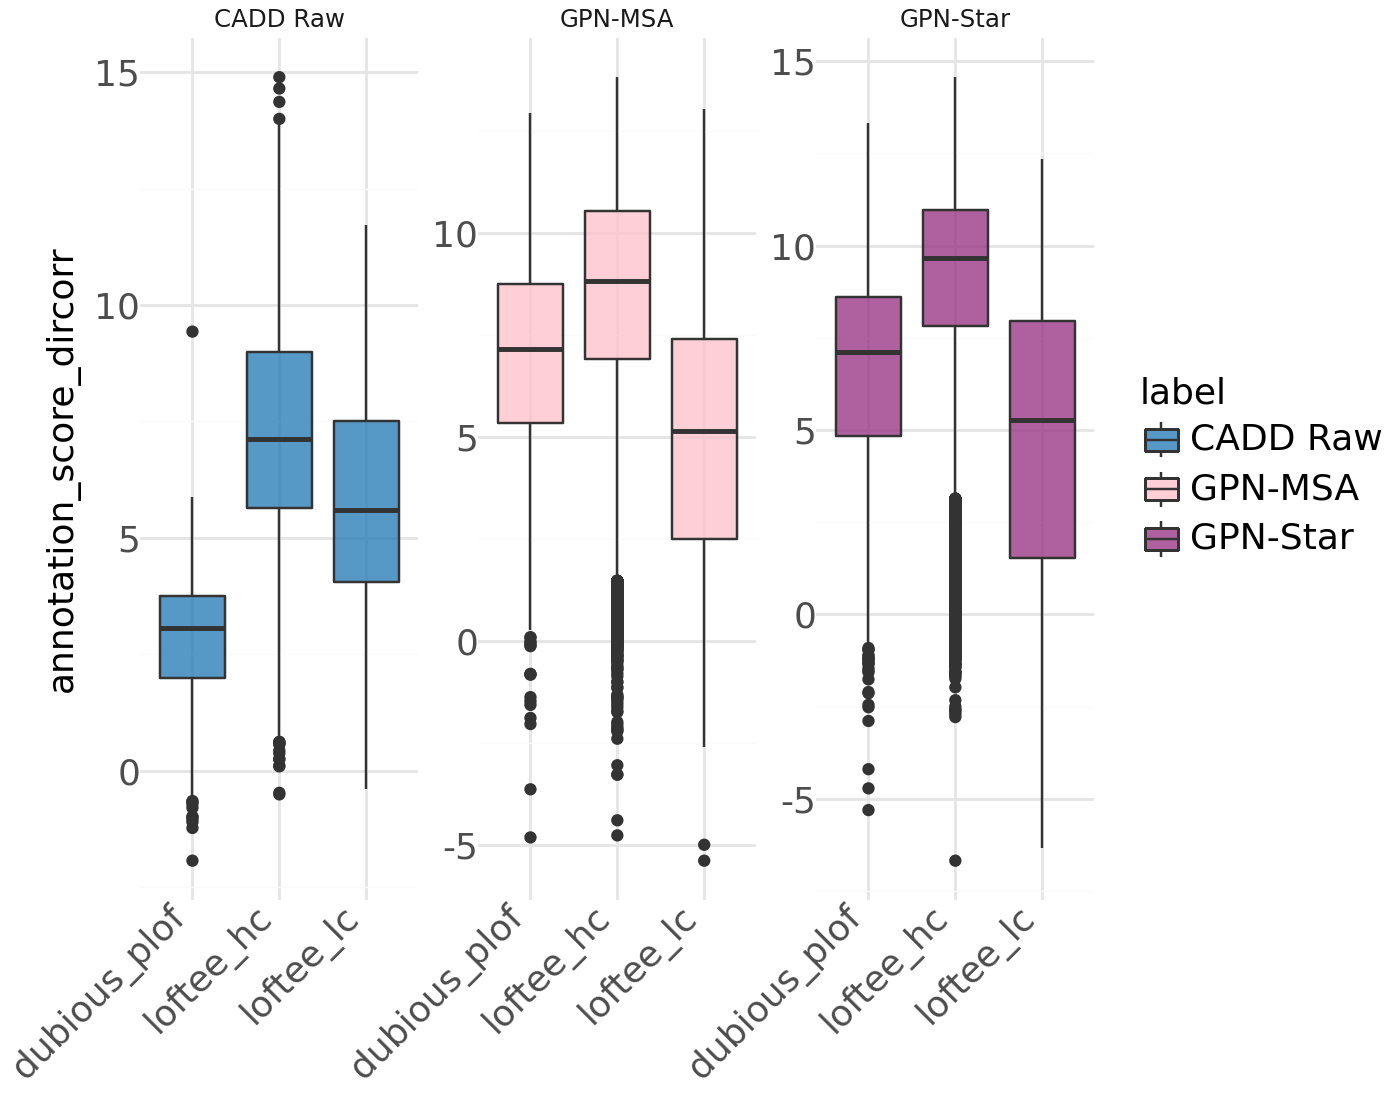

In [ ]:
color_dict = dict(zip(anno_config_df['label'], anno_config_df['color']))

(
    ggplot(
        plof_df,
        aes(y='annotation_score_dircorr', x='plof_type', fill='label')
    )
    + geom_boxplot(width=0.75, alpha=0.75)
    + facet_wrap('~label', scales='free_y', ncol=3)
    + scale_fill_manual(values=color_dict)
    + labs(x='')
    + theme_minimal()
    + theme(
        figure_size=(7, 5.5),
        axis_text_x=element_text(rotation=45, hjust=1),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
    )
)

## Look at Phenotypes

In [6]:
plof_stats_df = (
    plof_df
    .group_by(['label', 'plof_type'])
    .agg(
        n_variants = pl.len(),
        mean_annotation_score = pl.col('annotation_score_dircorr').mean(),
        std_annotation_score = pl.col('annotation_score_dircorr').std(),
        qtl25_annotation_score = pl.col('annotation_score_dircorr').quantile(0.25),
        qtl75_annotation_score = pl.col('annotation_score_dircorr').quantile(0.75),
    )
    .sort(['label', 'plof_type'])
)

plof_stats_df

label,plof_type,n_variants,mean_annotation_score,std_annotation_score,qtl25_annotation_score,qtl75_annotation_score
str,str,u64,f32,f32,f32,f32
"""CADD Raw""","""dubious_plof""",1241,2.820765,1.254906,1.998258,3.751317
"""CADD Raw""","""loftee_hc""",21607,7.296275,1.977515,5.650827,8.986744
"""CADD Raw""","""loftee_lc""",1191,5.608736,2.488167,4.064864,7.52164
"""GPN-MSA""","""dubious_plof""",1241,6.959175,2.706017,5.35,8.76
"""GPN-MSA""","""loftee_hc""",21607,8.468368,2.793586,6.92,10.54
"""GPN-MSA""","""loftee_lc""",1191,5.065041,2.992048,2.5,7.39
"""GPN-Star""","""dubious_plof""",1241,6.500586,2.974396,4.837677,8.599945
"""GPN-Star""","""loftee_hc""",21607,8.990859,2.845909,7.833182,10.957524
"""GPN-Star""","""loftee_lc""",1191,4.888409,3.612128,1.547046,7.95476


In [7]:
anno = "GPN-Star"

dbs_plof_df = (
    plof_df
    .filter(
        (pl.col('label') == anno) &
        (pl.col('plof_type') == 'dubious_plof') &
        (pl.col('annotation_score_dircorr') > plof_stats_df.filter(
                (pl.col('label') == anno) &
                (pl.col('plof_type') == 'loftee_hc')
            )
            .select('qtl75_annotation_score')
            .item()
        )
    )
)

dbs_plof_df

id,region,gene_name,annotation,annotation_score,plof_type,plof_score,category,color,label,annotation_dir,annotation_score_dircorr
str,str,str,str,f64,str,i8,str,str,str,i8,f32
"""chr11:11956173:T:C""","""ENSG00000170242""","""USP47""","""gpn_star_llr_calibrated_mean""",-10.967503,"""dubious_plof""",1,"""conservation""","""#942c80""","""GPN-Star""",-1,10.967503
"""chr2:209730396:G:T""","""ENSG00000078018""","""MAP2""","""gpn_star_llr_calibrated_mean""",-12.674371,"""dubious_plof""",1,"""conservation""","""#942c80""","""GPN-Star""",-1,12.674371
"""chr20:38488434:T:G""","""ENSG00000170471""","""RALGAPB""","""gpn_star_llr_calibrated_mean""",-12.223708,"""dubious_plof""",1,"""conservation""","""#942c80""","""GPN-Star""",-1,12.223708
"""chr6:16238695:T:A""","""ENSG00000137198""","""GMPR""","""gpn_star_llr_calibrated_mean""",-11.219679,"""dubious_plof""",1,"""conservation""","""#942c80""","""GPN-Star""",-1,11.219679
"""chr6:16238696:G:T""","""ENSG00000137198""","""GMPR""","""gpn_star_llr_calibrated_mean""",-11.345552,"""dubious_plof""",1,"""conservation""","""#942c80""","""GPN-Star""",-1,11.345552
…,…,…,…,…,…,…,…,…,…,…,…
"""chr1:166876232:A:T""","""ENSG00000152382""","""TADA1""","""gpn_star_llr_calibrated_mean""",-11.005068,"""dubious_plof""",1,"""conservation""","""#942c80""","""GPN-Star""",-1,11.005068
"""chr22:40323239:T:C""","""ENSG00000100354""","""TNRC6B""","""gpn_star_llr_calibrated_mean""",-11.473181,"""dubious_plof""",1,"""conservation""","""#942c80""","""GPN-Star""",-1,11.473181
"""chr22:40323241:A:T""","""ENSG00000100354""","""TNRC6B""","""gpn_star_llr_calibrated_mean""",-13.33519,"""dubious_plof""",1,"""conservation""","""#942c80""","""GPN-Star""",-1,13.33519


In [8]:
dbs_plof_df['gene_name'].value_counts(sort=True)

gene_name,count
str,u64
"""GMPR""",2
"""PAX2""",2
"""TADA1""",2
"""TNRC6B""",2
"""USP47""",1
…,…
"""EPC2""",1
"""HNF1A""",1
"""SOX2""",1


In [9]:
# Get gene trait associations

plof = pl.read_parquet('/home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie.parquet').with_columns(
    phenotype = (pl.col('trait') + '_int'),
    region = pl.col('gene_id'),
    rvat_pval = (10** -pl.col("neg_log10p")),
).filter(
    (pl.col('trait_type') == 'quantitative')
)

loftee_corr = pl.read_parquet("/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_wgs_EUR_genebass1e6_maf1e3_snp_consistent.parquet")

gene_trait_df = loftee_corr.join(plof[['region', 'phenotype', 'beta', 'rvat_pval']], on=['region', 'phenotype'], how='inner').filter(
    pl.col('loftee_corr')*pl.col('beta') > 0
).with_columns(
    corr_dir = pl.col('loftee_corr')/pl.col('loftee_corr').abs()
)
gene_trait_df

region,gene_name,phenotype,loftee_corr,n_variants,beta,rvat_pval,corr_dir
str,str,str,f64,u64,f64,f64,f64
"""ENSG00000116183""","""PAPPA2""","""arm_fatfree_mass_right_int""",-0.014747,82603,-0.195409,9.1637e-8,-1.0
"""ENSG00000129083""","""COPB1""","""arm_fatfree_mass_right_int""",-0.014338,13594,-0.397279,0.006626,-1.0
"""ENSG00000100578""","""KIAA0586""","""arm_fatfree_mass_right_int""",-0.010787,28541,-0.058463,0.000305,-1.0
"""ENSG00000157766""","""ACAN""","""arm_fatfree_mass_right_int""",-0.036259,20244,-0.436618,6.0395e-11,-1.0
"""ENSG00000140443""","""IGF1R""","""arm_fatfree_mass_right_int""",-0.013644,82469,-0.412619,2.8609e-8,-1.0
…,…,…,…,…,…,…,…
"""ENSG00000112077""","""RHAG""","""reticulocyte_count_int""",0.033239,9849,0.952411,1.8038e-41,1.0
"""ENSG00000029534""","""ANK1""","""reticulocyte_count_int""",0.02685,54620,0.656849,2.1682e-10,1.0
"""ENSG00000197969""","""VPS13A""","""reticulocyte_count_int""",0.003971,55477,0.176348,2.1188e-7,1.0


In [12]:
appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_genebass1e6_PRScorr_with_percentiles.parquet")

# Create a lazy frame with the unique keys
anno_keys = plof_df.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)

In [11]:
anno_pheno_df = (
    # A. Use a semi join for efficient filtering (more memory-safe than 'is_in')
    appv
    # B. Join the other two dataframes
    .join(
        plof_df.lazy().drop([c for c in plof_df.columns if 'is_nan' in c]), 
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .with_columns(
        mean_pheno_value_dircor = pl.col('mean_pheno_value')*pl.col('corr_dir')
    )
    .collect(engine='streaming')
)

anno_pheno_df

id,phenotype,mean_pheno_value,n_individuals,region,gene_name,annotation,annotation_score,plof_type,plof_score,category,color,label,annotation_dir,annotation_score_dircorr,gene_name_right,loftee_corr,n_variants,beta,rvat_pval,corr_dir,mean_pheno_value_dircor
str,str,f32,u32,str,str,str,f64,str,i8,str,str,str,i8,f32,str,f64,u64,f64,f64,f64,f64
"""chr2:21012484:C:A""","""alanine_aminotransferase_int""",2.032735,1,"""ENSG00000084674""","""APOB""","""gpn_score""",-9.0,"""loftee_hc""",1,"""conservation""","""pink""","""GPN-MSA""",-1,9.0,"""APOB""",0.028104,11795,0.190438,9.6228e-11,1.0,2.032735
"""chr2:21012484:C:A""","""alanine_aminotransferase_int""",2.032735,1,"""ENSG00000084674""","""APOB""","""gpn_star_llr_calibrated_mean""",-8.805655,"""loftee_hc""",1,"""conservation""","""#942c80""","""GPN-Star""",-1,8.805655,"""APOB""",0.028104,11795,0.190438,9.6228e-11,1.0,2.032735
"""chr2:21012484:C:A""","""alanine_aminotransferase_int""",2.032735,1,"""ENSG00000084674""","""APOB""","""cadd_raw""",9.000214,"""loftee_hc""",1,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,9.000214,"""APOB""",0.028104,11795,0.190438,9.6228e-11,1.0,2.032735
"""chr2:21005754:G:T""","""alanine_aminotransferase_int""",-1.290463,1,"""ENSG00000084674""","""APOB""","""gpn_score""",-8.14,"""loftee_hc""",1,"""conservation""","""pink""","""GPN-MSA""",-1,8.14,"""APOB""",0.028104,11795,0.190438,9.6228e-11,1.0,-1.290463
"""chr2:21005754:G:T""","""alanine_aminotransferase_int""",-1.290463,1,"""ENSG00000084674""","""APOB""","""gpn_star_llr_calibrated_mean""",-9.125299,"""loftee_hc""",1,"""conservation""","""#942c80""","""GPN-Star""",-1,9.125299,"""APOB""",0.028104,11795,0.190438,9.6228e-11,1.0,-1.290463
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr20:37254313:G:A""","""whole_body_water_mass_int""",-0.230922,8,"""ENSG00000118702""","""GHRH""","""gpn_star_llr_calibrated_mean""",-4.778859,"""loftee_hc""",1,"""conservation""","""#942c80""","""GPN-Star""",-1,4.778859,"""GHRH""",-0.023754,4585,-0.322347,2.8641e-8,-1.0,0.230922
"""chr20:37254313:G:A""","""whole_body_water_mass_int""",-0.230922,8,"""ENSG00000118702""","""GHRH""","""cadd_raw""",9.07018,"""loftee_hc""",1,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,9.07018,"""GHRH""",-0.023754,4585,-0.322347,2.8641e-8,-1.0,0.230922
"""chr20:37254330:C:T""","""whole_body_water_mass_int""",-0.459923,7,"""ENSG00000118702""","""GHRH""","""gpn_score""",-4.9,"""loftee_hc""",1,"""conservation""","""pink""","""GPN-MSA""",-1,4.9,"""GHRH""",-0.023754,4585,-0.322347,2.8641e-8,-1.0,0.459923


In [22]:
a = anno_pheno_df.group_by(['gene_name', 'phenotype']).agg(pl.len()).sort('len', descending=True).filter(pl.col('gene_name')=='APOB')
a

gene_name,phenotype,len
str,str,u64
"""APOB""","""seated_height_int""",258
"""APOB""","""standing_height_int""",258
"""APOB""","""triglycerides_int""",255
"""APOB""","""creatinine_int""",255
"""APOB""","""cholesterol_int""",255
…,…,…
"""APOB""","""vitamin_d_int""",252
"""APOB""","""hdl_cholesterol_int""",249
"""APOB""","""apolipoprotein_a_int""",249


In [24]:
anno_pheno_df.filter((pl.col('gene_name')=='APOB') & (pl.col('phenotype')=='ldl_direct_int'))

id,phenotype,mean_pheno_value,n_individuals,region,gene_name,annotation,annotation_score,plof_type,plof_score,category,color,label,annotation_dir,annotation_score_dircorr,gene_name_right,loftee_corr,n_variants,beta,rvat_pval,corr_dir,mean_pheno_value_dircor
str,str,f32,u32,str,str,str,f64,str,i8,str,str,str,i8,f32,str,f64,u64,f64,f64,f64,f64
"""chr2:21005754:G:T""","""ldl_direct_int""",-1.912427,1,"""ENSG00000084674""","""APOB""","""gpn_score""",-8.14,"""loftee_hc""",1,"""conservation""","""pink""","""GPN-MSA""",-1,8.14,"""APOB""",-0.12425,11789,-1.05153,1.7865e-262,-1.0,1.912427
"""chr2:21005754:G:T""","""ldl_direct_int""",-1.912427,1,"""ENSG00000084674""","""APOB""","""gpn_star_llr_calibrated_mean""",-9.125299,"""loftee_hc""",1,"""conservation""","""#942c80""","""GPN-Star""",-1,9.125299,"""APOB""",-0.12425,11789,-1.05153,1.7865e-262,-1.0,1.912427
"""chr2:21005754:G:T""","""ldl_direct_int""",-1.912427,1,"""ENSG00000084674""","""APOB""","""cadd_raw""",9.474796,"""loftee_hc""",1,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,9.474796,"""APOB""",-0.12425,11789,-1.05153,1.7865e-262,-1.0,1.912427
"""chr2:21012484:C:A""","""ldl_direct_int""",-2.779992,1,"""ENSG00000084674""","""APOB""","""gpn_score""",-9.0,"""loftee_hc""",1,"""conservation""","""pink""","""GPN-MSA""",-1,9.0,"""APOB""",-0.12425,11789,-1.05153,1.7865e-262,-1.0,2.779992
"""chr2:21012484:C:A""","""ldl_direct_int""",-2.779992,1,"""ENSG00000084674""","""APOB""","""gpn_star_llr_calibrated_mean""",-8.805655,"""loftee_hc""",1,"""conservation""","""#942c80""","""GPN-Star""",-1,8.805655,"""APOB""",-0.12425,11789,-1.05153,1.7865e-262,-1.0,2.779992
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr2:21003152:C:T""","""ldl_direct_int""",-0.840164,1,"""ENSG00000084674""","""APOB""","""gpn_star_llr_calibrated_mean""",-4.698001,"""loftee_lc""",1,"""conservation""","""#942c80""","""GPN-Star""",-1,4.698001,"""APOB""",-0.12425,11789,-1.05153,1.7865e-262,-1.0,0.840164
"""chr2:21003152:C:T""","""ldl_direct_int""",-0.840164,1,"""ENSG00000084674""","""APOB""","""cadd_raw""",7.78305,"""loftee_lc""",1,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,7.78305,"""APOB""",-0.12425,11789,-1.05153,1.7865e-262,-1.0,0.840164
"""chr2:21009331:G:A""","""ldl_direct_int""",-2.352204,1,"""ENSG00000084674""","""APOB""","""gpn_score""",-3.11,"""loftee_hc""",1,"""conservation""","""pink""","""GPN-MSA""",-1,3.11,"""APOB""",-0.12425,11789,-1.05153,1.7865e-262,-1.0,2.352204


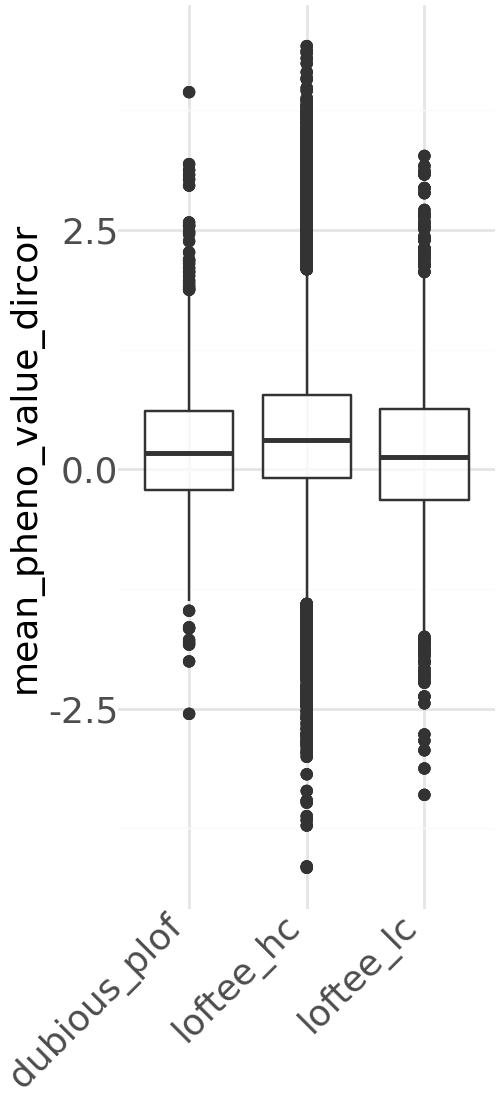

In [ ]:
(
    ggplot(
        anno_pheno_df[['gene_name', 'phenotype', 'plof_type', 'mean_pheno_value_dircor', 'label']].unique(),
        # anno_pheno_df[['gene_name', 'phenotype', 'plof_type', 'mean_pheno_value_dircor', 'label']].unique().filter((pl.col('gene_name')=='APOB') & (pl.col('phenotype')=='ldl_direct_int')), 
        aes(x='plof_type', y='mean_pheno_value_dircor')
    )
    + geom_boxplot(width=0.75, alpha=0.75)
    + labs(x='')
    + theme_minimal()
    + theme(
        figure_size=(2.5, 5.5),
        axis_text_x=element_text(rotation=45, hjust=1),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
    )
)

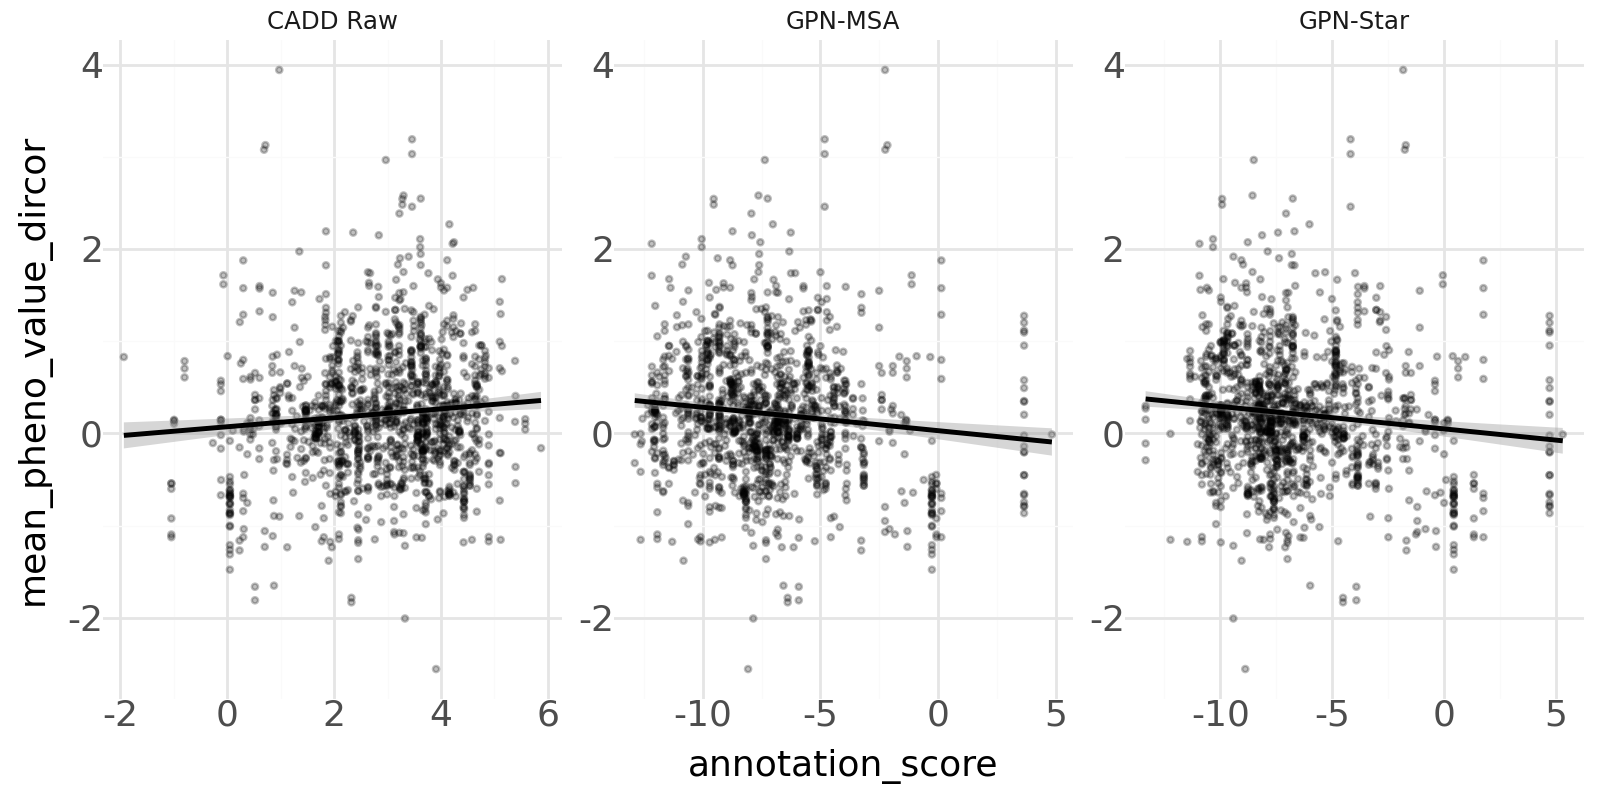

In [42]:
from scipy.stats import spearmanr

spearman_corr, p_value = spearmanr(
    anno_pheno_df['annotation_score'],
    anno_pheno_df['mean_pheno_value_dircor']
)

(
    ggplot(
        anno_pheno_df.filter(pl.col('plof_type')=='dubious_plof'),
        aes(x='annotation_score', y='mean_pheno_value_dircor')
    )
    + geom_point(color='black', alpha=0.25, size=0.75)
    + facet_wrap('~label', scales='free', ncol=3)
    + stat_smooth(method='glm', se=True)
    + theme_minimal()
    + theme(
        figure_size=(8, 4),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
    )
)

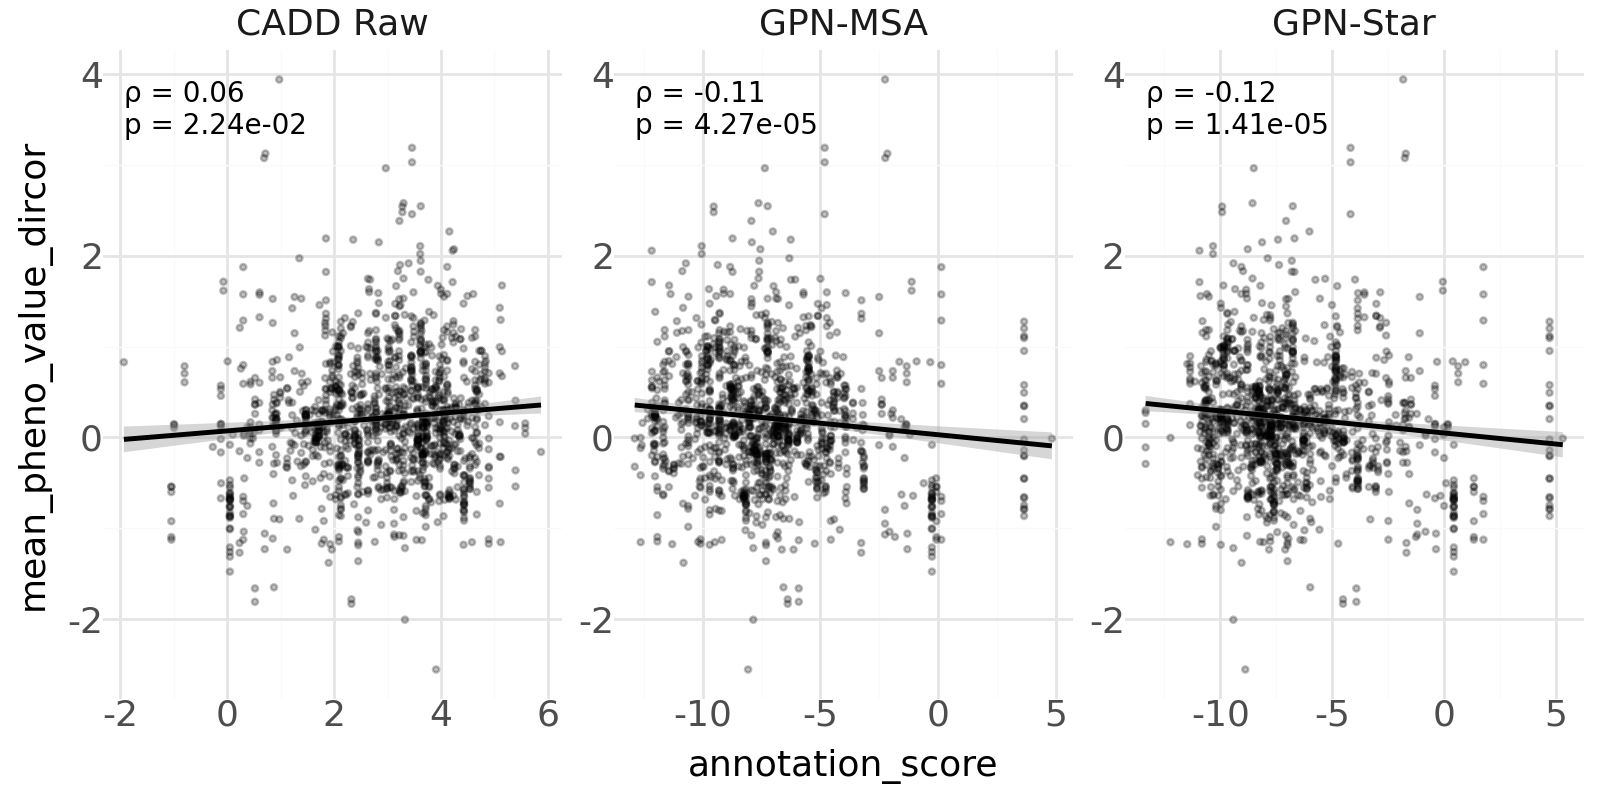

In [47]:
# 1. PREPARE DATA
plot_data = anno_pheno_df.filter(pl.col('plof_type') == 'dubious_plof')

# 2. DEFINE CUSTOM FUNCTION
def get_spearman_stats(df):
    res = spearmanr(df['annotation_score'], df['mean_pheno_value_dircor'])
    
    # Use Python's f-string here (it supports .2e, .2f, etc.)
    txt = f"ρ = {res.statistic:.2f}\np = {res.pvalue:.2e}"
    
    return pl.DataFrame({
        "label": df['label'][0],
        "label_text": [txt],  # <--- Return the pre-formatted string
        "x_pos": [df['annotation_score'].min()],
        "y_pos": [df['mean_pheno_value_dircor'].max()]
    })

# 3. APPLY TO GROUPS
cor_df = (
    plot_data
    .group_by("label", maintain_order=True)
    .map_groups(get_spearman_stats)
)

# 4. PLOT
(
    ggplot(plot_data, aes(x='annotation_score', y='mean_pheno_value_dircor'))
    + geom_point(color='black', alpha=0.25, size=0.75)
    + geom_smooth(method='lm', se=True)
    
    # Add the text with the p-value
    + geom_text(
        data=cor_df,
        mapping=aes(x='x_pos', y='y_pos', label='label_text'),
        ha='left',
        va='top',
        size=10,
        inherit_aes=False
    )
    
    + facet_wrap('~label', scales='free', ncol=3)
    + theme_minimal()
    + theme(
        figure_size=(8, 4),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        strip_text=element_text(size=13)
    )
)